In [11]:
# general
import pandas as pd
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
import os
# for textblob
from textblob import TextBlob

# for finbert
from transformers import pipeline
finbert = pipeline("text-classification", model="ProsusAI/finbert")

# for nltk
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# for gpt
import time

from openai import OpenAI
k2_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=k2_key)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [3]:
# creating functions for sentiments for text block and vader and finbert

def vadernltk_sentiment(headline):
    scores = sia.polarity_scores(headline)
    compound = scores['compound']
    
    if compound > 0.05:
        return "Positive"
    elif compound < -0.05:
        return "Negative"
    else:
        return "Neutral"

def textblob_sentiment(headline):
    score = TextBlob(headline).sentiment.polarity
    
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

def finbert_sentiment(headline):
    result = finbert(headline)              # [{'label': 'positive', 'score': 0.42}, ...]
    best = max(result, key=lambda x: x["score"])  # pick the highest confidence prediction
    return best["label"].title()


In [4]:
# creating function for gpt

system_prompt = """You are classifying the ECONOMIC IMPACT of East African financial news headlines.

Positive:
Likely improves growth, stability, investment, consumer conditions, or business activity.

Negative:
announcements, budget approvals, and new guidelines where no outcome is speculated yet, or steady state with no directional signal

Neutral:
Informational updates, announcements, or events without a clear positive or negative economic implication.

Focus on the likely economic effect implied by the headline, not emotional tone.

Return only:
1. Positive
2. Negative
3. Neutral
""" 

def openai_sentiment_batch(headlines_df, batch_size=25, system_prompt=system_prompt):
    headlines = headlines_df.tolist()
    VALID_LABELS = {"Positive", "Negative", "Neutral"}
    max_retries = 3

    for attempt in range(1, max_retries + 1):

        print(f"\nAttempt {attempt}...\n")

        all_results = []

        batches = [
            headlines[i:i+batch_size]
            for i in range(0, len(headlines), batch_size)
        ]

        for batch_num, batch in enumerate(batches):

            print(f"Processing batch {batch_num + 1}/{len(batches)} ({len(batch)} headlines)...")

            numbered = "\n".join(
                [f"{i+1}. {h}" for i, h in enumerate(batch)]
            )

            try:
                response = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": numbered}
                    ],
                    temperature=0
                )

                lines = response.choices[0].message.content.strip().split("\n")

                batch_results = [
                    line.split(". ", 1)[1].strip()
                    for line in lines
                    if ". " in line
                ]

                all_results.extend(batch_results)

            except Exception as e:
                print(f"Batch {batch_num + 1} failed: {e}")
                all_results.extend(["Error"] * len(batch))

            if batch_num < len(batches) - 1:
                time.sleep(1)

        # validation checks
        correct_length = len(all_results) == len(headlines)
        valid_labels = set(all_results).issubset(VALID_LABELS)

        print(f"\nOutput count: {len(all_results)} / {len(headlines)}")
        print(f"Unique outputs: {set(all_results)}")

        if correct_length and valid_labels:
            # print("Validation passed.")
            return all_results

        print("Validation failed. Retrying...\n")

    print("App failed after 3 attempts.")
    return None

In [5]:
df = pd.read_csv("tz_eac_economic_headlines.csv")
df_comparison = df[["headline","sentiment"]].copy() 
df.head()

,date,headline,source,category,sentiment,tzs_usd_rate,inflation_rate,bot_policy_rate
0,2021-01-05,Bank of Tanzania holds policy rate steady amid...,Daily News,Policy,Neutral,2296,3.1,5.0
1,2021-01-08,Tanzanian shilling opens week firmer as dollar...,The Citizen,Forex,Positive,2291,3.1,5.0
2,2021-01-12,KCB Tanzania reports 18% rise in mobile loan d...,Business Daily Africa,Fintech,Positive,2294,3.1,5.0
3,2021-01-15,Tanzania Revenue Authority misses January targ...,The EastAfrican,Taxation,Negative,2297,3.2,5.0
4,2021-01-19,Cashew export volumes from Mtwara port fall sh...,Mwananchi,Agriculture,Negative,2300,3.2,5.0


In [6]:
# text blob sentiment analysis
df_comparison["textblob"] = df_comparison["headline"].apply(textblob_sentiment)
df_comparison["vadernltk"] = df_comparison["headline"].apply(vadernltk_sentiment)
df_comparison["finbert"] = df_comparison["headline"].apply(finbert_sentiment)
df_comparison.head()

,headline,sentiment,textblob,vadernltk,finbert
0,Bank of Tanzania holds policy rate steady amid...,Neutral,Positive,Negative,Positive
1,Tanzanian shilling opens week firmer as dollar...,Positive,Neutral,Positive,Positive
2,KCB Tanzania reports 18% rise in mobile loan d...,Positive,Neutral,Neutral,Positive
3,Tanzania Revenue Authority misses January targ...,Negative,Neutral,Negative,Negative
4,Cashew export volumes from Mtwara port fall sh...,Negative,Neutral,Neutral,Negative


In [7]:
df_comparison["openai"] = openai_sentiment_batch(df_comparison["headline"], 50)
df_comparison.head()


Attempt 1...

Processing batch 1/11 (50 headlines)...
Processing batch 2/11 (50 headlines)...
Processing batch 3/11 (50 headlines)...
Processing batch 4/11 (50 headlines)...
Processing batch 5/11 (50 headlines)...
Processing batch 6/11 (50 headlines)...
Processing batch 7/11 (50 headlines)...
Processing batch 8/11 (50 headlines)...
Processing batch 9/11 (50 headlines)...
Processing batch 10/11 (50 headlines)...
Processing batch 11/11 (4 headlines)...

Output count: 504 / 504
Unique outputs: {'Positive', 'Negative', 'Neutral'}


,headline,sentiment,textblob,vadernltk,finbert,openai
0,Bank of Tanzania holds policy rate steady amid...,Neutral,Positive,Negative,Positive,Negative
1,Tanzanian shilling opens week firmer as dollar...,Positive,Neutral,Positive,Positive,Positive
2,KCB Tanzania reports 18% rise in mobile loan d...,Positive,Neutral,Neutral,Positive,Positive
3,Tanzania Revenue Authority misses January targ...,Negative,Neutral,Negative,Negative,Negative
4,Cashew export volumes from Mtwara port fall sh...,Negative,Neutral,Neutral,Negative,Negative


In [8]:
true_labels = df_comparison['sentiment']
textblob_labels = df_comparison['textblob']
vader_labels = df_comparison['vadernltk']
finbert_labels = df_comparison['finbert']
openai_labels = df_comparison['openai']

print(f"TextBlob accuracy:  {accuracy_score(true_labels, textblob_labels):.2%}")
print(f"VADER accuracy:     {accuracy_score(true_labels, vader_labels):.2%}")
print(f"FinBERT accuracy:   {accuracy_score(true_labels, finbert_labels):.2%}")
print(f"Open ai accuracy:   {accuracy_score(true_labels, openai_labels):.2%}")

TextBlob accuracy:  28.17%
VADER accuracy:     50.00%
FinBERT accuracy:   66.67%
Open ai accuracy:   92.06%


AttributeError: 'Series' object has no attribute 'columns'

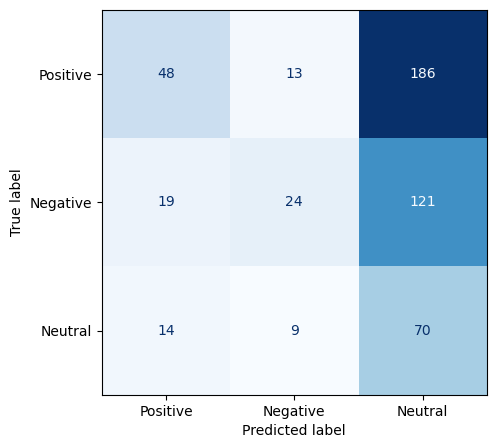

In [15]:
models =[textblob_labels, vader_labels, finbert_labels, openai_labels]

for model in models:
    labels = ['Positive', 'Negative', 'Neutral']
    
    cm = confusion_matrix(true_labels,model, labels=labels)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model.columns().tostring())
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

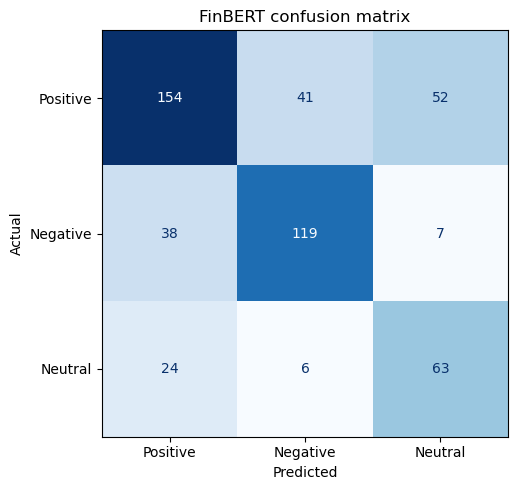

In [12]:
labels = ['Positive', 'Negative', 'Neutral']
    
cm = confusion_matrix(true_labels, finbert_labels, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('FinBERT confusion matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()